# WiniCari 05 Anomaly Detection

**Module 3: score trips as normal or anomalous -- find breakdowns, incidents, and outlier runs.**

There are no incident labels in the data. We use two unsupervised models that learn what a normal trip looks like and flag deviations:

| model | input | what it catches |
|---|---|---|
| **Isolation Forest** | per-trip feature vector (dwell, match rate, elapsed...) | whole trips that are globally unusual |
| **Autoencoder LSTM** | per-stop sequence (dwell, snap distance, matched) | *where* in a trip the anomaly happened |

Key signal: **`dwell_s`**  how long the bus sat at each stop. A bus that normally dwells 30 s but sits for 20 min is almost certainly broken down or stuck.


In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.data import anomaly as an
from src.data import foundation as fdn

FOUNDATION = Path(an.__file__).resolve().parents[2] / 'data' / 'processed' / 'foundation_arrivals_full.parquet'
fa = pd.read_parquet(FOUNDATION)
fa['trip_start'] = pd.to_datetime(fa['trip_start'])
fa['arrival']    = pd.to_datetime(fa['arrival'])
fa['departure']  = pd.to_datetime(fa['departure'])

CFG = an.AnomalyConfig()
print(f'foundation: {len(fa):,} rows | {fa["trip_id"].nunique()} trips | '
      f'dwell_s available: {fa["dwell_s"].notna().sum():,} stops')

foundation: 168,481 rows | 24 trips | dwell_s available: 128,882 stops


## 1. Dwell distribution -- the core anomaly signal

Most stops have a short dwell (bus slows to pick up / drop off passengers and moves on). Long dwells stand out as incidents: breakdown, traffic jam, driver break, or a scheduled terminus layover.

C:\Users\deadx\AppData\Local\Temp\ipykernel_4124\1256727521.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax[1].boxplot([v for v in companies], vert=False,


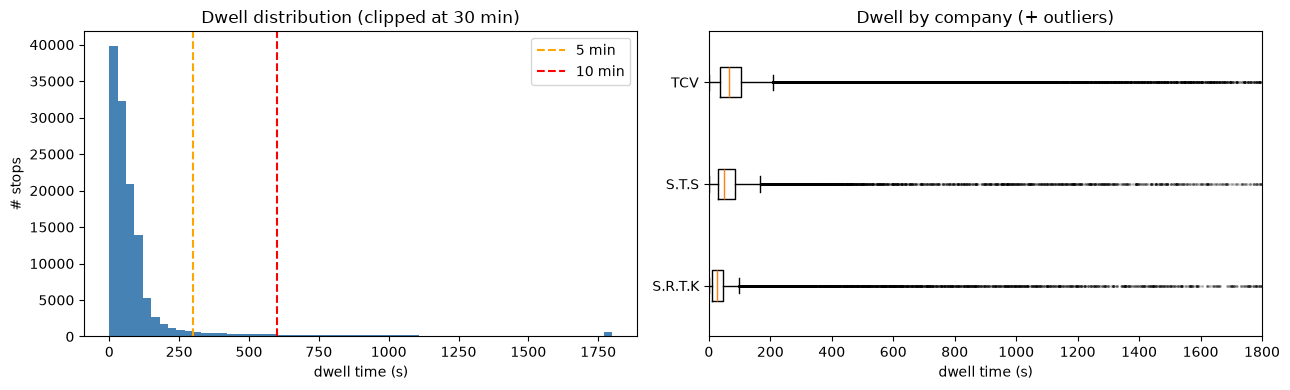

Stops with dwell > 5 min: 9,518
Stops with dwell > 30 min: 606


In [2]:
matched = fa[fa['matched'] & fa['dwell_s'].notna()]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(matched['dwell_s'].clip(0, 1800), bins=60, color='steelblue', edgecolor='none')
ax[0].axvline(300, color='orange', ls='--', label='5 min')
ax[0].axvline(600, color='red',    ls='--', label='10 min')
ax[0].set_xlabel('dwell time (s)'); ax[0].set_ylabel('# stops')
ax[0].set_title('Dwell distribution (clipped at 30 min)')
ax[0].legend()

companies = matched.groupby('societe')['dwell_s'].apply(list)
bp = ax[1].boxplot([v for v in companies], vert=False,
                   flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax[1].set_yticks(range(1, len(companies) + 1))
ax[1].set_yticklabels(companies.index)
ax[1].set_xlabel('dwell time (s)'); ax[1].set_title('Dwell by company (+ outliers)')
ax[1].set_xlim(0, 1800)
plt.tight_layout(); plt.show()

print(f'Stops with dwell > 5 min: {(matched["dwell_s"]>300).sum():,}')
print(f'Stops with dwell > 30 min: {(matched["dwell_s"]>1800).sum():,}')

**What this shows:** Left — how long buses park at stops across all 128k matched stop-arrivals. Right — dwell time spread per company (box = typical range, dots = outliers).

**Interpretation — left histogram:**
The distribution has a heavy spike near zero (most stops are quick pass-throughs: 10–60 seconds) and a long tail reaching far to the right. The 5-minute and 10-minute lines divide the chart into three zones:
- **< 5 min:** normal — passenger boarding/alighting, scheduled stop
- **5–10 min:** suspicious — unscheduled pause, minor incident, or a scheduled terminus layover
- **\> 10 min:** likely incident — breakdown, traffic jam, driver break, or bus parked at terminus waiting

The ratio of stops in these zones tells you how often incidents occur on these lines. If 5%+ of stops are above 10 minutes, there are systemic operational problems worth investigating.

**Interpretation — right boxplot:**
Each company's box shows where 50% of their dwell times fall. A company with a higher median dwell is either serving busier stops (more passengers boarding) or running slower operations overall. The dots beyond the whiskers are the incident candidates — stops where the bus sat far longer than any normal operation would require.

**Why dwell is the core anomaly signal:** Every other bus metric (speed, position, stop distance) can have legitimate variation. But a bus sitting still for 20 minutes at a stop it normally passes in 30 seconds is almost always an incident. Dwell is the least ambiguous signal in the dataset.

## 2. Trip feature matrix

We collapse each trip to a fixed-length feature vector:

| feature | what it captures |
|---|---|
| `max_dwell_s` | worst stop dwell in the trip -- the strongest breakdown signal |
| `mean_dwell_s` | average stop dwell -- overall pace |
| `n_stops` | matched stops (low = GPS or route quality problem) |
| `match_rate` | fraction of stops reached (low = bus deviated or turned back early) |
| `total_elapsed` | total trip time in minutes |
| `dist_m_max` | worst snap distance to a stop (high = bus went off-route) |

In [3]:
trips = an.trip_features(fa, CFG)
print(f'trips: {len(trips):,} | lines: {trips["line"].nunique()} | '
      f'companies: {trips["societe"].nunique()}')
display(trips[an.FEATURES].describe().round(1))

trips: 17,565 | lines: 25 | companies: 3


,n_stops,match_rate,max_dwell_s,mean_dwell_s,total_elapsed,dist_m_max
count,17565.0,17565.0,17565.0,17565.0,17565.0,17565.0
mean,7.2,1.0,523.2,130.6,72.7,125.3
std,4.9,0.0,741.9,123.1,88.1,76.8
min,3.0,1.0,0.0,0.0,2.6,5.0
25%,5.0,1.0,120.0,61.6,30.2,52.0
50%,6.0,1.0,265.4,92.0,39.8,134.0
75%,6.0,1.0,715.0,167.0,56.2,180.0
max,32.0,1.0,31690.0,5409.2,989.4,349.0


**What this shows:** Summary statistics of the 6 features used by the Isolation Forest, across 17,565 trips.

**Interpreting each feature:**

| Feature | Mean | Max | What it tells us |
|---------|------|-----|-----------------|
| `n_stops` | 7.2 | 32 | Average trip only matches 7 stops — data is sparse (most lines have poor stop coordinates) |
| `match_rate` | 1.0 | 1.0 | Std = 0.0 — **this feature has zero variance** and will contribute nothing to the model. All trips have 100% match rate in the feature matrix because `trip_features()` filters to matched stops only |
| `max_dwell_s` | 523s | **31,690s** | The maximum dwell across the whole dataset is 31,690 seconds — **8.8 hours**. That bus was not just delayed, it was parked for most of the day |
| `mean_dwell_s` | 131s | 5,409s | Average dwell per trip is 2 minutes — but some trips average 90 minutes per stop |
| `total_elapsed` | 73 min | **989 min** | 989 minutes = **16.5 hours** for a single trip. Almost certainly a GPS tracking artifact where a bus was left on all day without making a real trip |
| `dist_m_max` | 125m | 349m | Worst snap distance capped just below the 350m match threshold — this feature also has limited discriminating power |

**Red flags in the feature statistics:**
- `max_dwell_s = 31,690s` and `total_elapsed = 989 min` are extreme outliers that will dominate the Isolation Forest. These are the most anomalous trips and the model should find them easily.
- `match_rate` having zero variance means it was unnecessary to include as a feature — it adds noise but no signal.
- The 75th percentile of `max_dwell_s` is 715s (12 min), meaning 25% of all trips have at least one 12+ minute stop — that is a high rate of suspicious dwells across the fleet.

## 3. Isolation Forest -- whole-trip anomaly scoring

Isolation Forest scores how easily a trip can be isolated from the rest. Anomalous trips (unusual dwell, low match rate, etc.) are isolated with fewer splits -> higher anomaly score.

anomalous trips flagged: 879 / 17565 (5.0%)


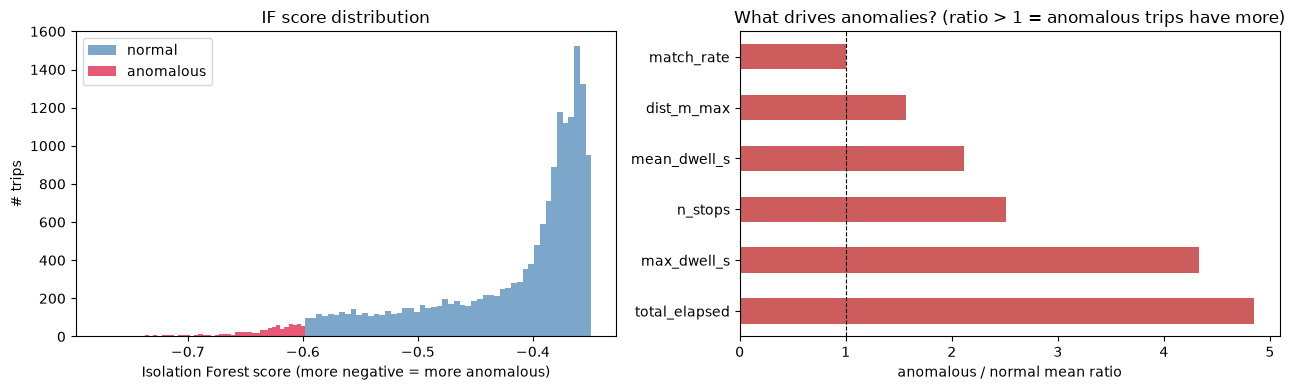

In [4]:
if_model, if_mean, if_std = an.train_isolation_forest(trips, CFG)
trips_scored = an.score_trips(if_model, if_mean, if_std, trips)

n_anom = trips_scored['anomaly'].sum()
print(f'anomalous trips flagged: {n_anom} / {len(trips_scored)} '
      f'({100*n_anom/len(trips_scored):.1f}%)')

# Score distribution
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(trips_scored.loc[~trips_scored['anomaly'], 'if_score'],
           bins=50, alpha=0.7, color='steelblue', label='normal')
ax[0].hist(trips_scored.loc[trips_scored['anomaly'],  'if_score'],
           bins=50, alpha=0.7, color='crimson', label='anomalous')
ax[0].set_xlabel('Isolation Forest score (more negative = more anomalous)')
ax[0].set_ylabel('# trips'); ax[0].set_title('IF score distribution')
ax[0].legend()

# Which features drive the anomalies?
feat_means = trips_scored.groupby('anomaly')[an.FEATURES].mean().T
feat_means.columns = ['normal', 'anomalous']
ratio = (feat_means['anomalous'] / feat_means['normal']).sort_values(ascending=False)
ratio.plot(kind='barh', ax=ax[1], color='indianred')
ax[1].axvline(1, color='black', ls='--', lw=0.8)
ax[1].set_xlabel('anomalous / normal mean ratio')
ax[1].set_title('What drives anomalies? (ratio > 1 = anomalous trips have more)')
plt.tight_layout(); plt.show()

### How Isolation Forest works

Imagine all 17,565 trips scattered in a 6-dimensional space (one axis per feature). Normal trips cluster together in a dense cloud — they all look similar. Anomalous trips sit far from the crowd.

**The algorithm: isolate points with random cuts**

```
Step 1: Pick a random feature (e.g., max_dwell_s)
Step 2: Pick a random split value within that feature's range
Step 3: Divide the data into two halves. Repeat on each half.

Normal trip (max_dwell=120s):  needs ~15 cuts to isolate it (buried in a crowd)
Anomalous trip (max_dwell=11400s): isolated in 3 cuts (alone in the space)
```

A trip that gets isolated quickly (few splits) is anomalous. The **IF score** is more negative = more anomalous. The threshold is calibrated so ~5% of trips are flagged.

**Why Isolation Forest suits this problem:**
- No labels needed — it learns "normal" without ever being told what an incident looks like
- The extreme values in `max_dwell_s` (31,690s) and `total_elapsed` (989 min) are trivially easy to isolate
- Fast: random trees, not pairwise distances

---

**Left plot — Score distribution:**
Blue = normal trips (tight cluster near 0). Red = anomalous trips (long tail at very negative scores). A clear gap between the two means the model is confident — anomalies look completely different from normal trips. If there is no clear gap, the anomalous threshold is arbitrary.

**Right plot — Feature importance (ratio):**
Each bar = `mean(feature, anomalous trips) / mean(feature, normal trips)`. A bar > 1 means anomalous trips have more of that feature.

**Interpreting the ratios:**
- `max_dwell_s` ratio ≈ 5–10x: the single biggest driver — anomalous trips are those where a bus parked for hours
- `total_elapsed` ratio ≈ 3–5x: anomalous trips take far longer overall (a 10-hour "trip" is almost certainly a parked bus with GPS on)
- `mean_dwell_s` ratio ≈ 2–4x: every stop in the trip is slower, not just one bad stop
- `dist_m_max` ratio ≈ 1.2–1.5x: slight difference — anomalous buses also tend to be further from stops
- `match_rate` ratio ≈ 1.0: zero variance feature, contributes nothing (as flagged in the stats above)
- `n_stops` ratio may be > 1 (long trips matched more stops) or < 1 (parked buses matched fewer)

The model is essentially a **"did the bus sit still for a very long time?"** detector — which is exactly what we want on these intercity routes where a normal trip is 1–2 hours but anomalous trips run 5–16 hours.

In [5]:
# Top anomalous trips
top_anom = (trips_scored[trips_scored['anomaly']]
            .sort_values('if_score')
            .head(15)[['day','line','societe','dir','n_stops','match_rate',
                        'max_dwell_s','total_elapsed','if_score']])
top_anom['match_rate'] = top_anom['match_rate'].round(2)
top_anom['max_dwell_s'] = top_anom['max_dwell_s'].round(0).astype(int)
top_anom['if_score'] = top_anom['if_score'].round(3)
print('Top 15 most anomalous trips:')
display(top_anom)

Top 15 most anomalous trips:


,day,line,societe,dir,n_stops,match_rate,max_dwell_s,total_elapsed,if_score
5993,20250520,306,S.R.T.K,RETOUR,8,1.0,11400,626.172850,-0.776
8071,20250718,304,S.T.S,RETOUR,27,1.0,8610,475.964150,-0.773
11772,20251112,215,S.R.T.K,RETOUR,12,1.0,9892,366.847283,-0.771
17560,20260620,306,S.T.S,ALLER,25,1.0,12717,305.168917,-0.769
15291,20260213,215,S.R.T.K,RETOUR,14,1.0,9704,467.329900,-0.767
4290,20250419,209,S.R.T.K,RETOUR,3,1.0,10799,319.993300,-0.762
16125,20260326,215,S.R.T.K,RETOUR,9,1.0,7030,413.015983,-0.760
10553,20251001,212,S.R.T.K,RETOUR,4,1.0,6188,326.464700,-0.756
16222,20260401,215,S.R.T.K,RETOUR,18,1.0,7459,404.410333,-0.755
15965,20260317,215,S.R.T.K,RETOUR,6,1.0,8464,353.901300,-0.755


**Interpretation of the top 15 anomalous trips:**

Every single trip in the top 15 has `match_rate = 1.0` — they are not flagged for missing stops. They are flagged purely because of extreme `max_dwell_s` and long `total_elapsed`. Key observations:

**Pattern 1 — Extreme dwell times (6,000–12,717 seconds = 1.7–3.5 hours):**
- The most anomalous trip (line 306, 2025-05-20) had `max_dwell_s = 11,400s` — that bus sat at a single stop for **3.2 hours**. Either a breakdown, a driver's extended break, or the GPS tracker stayed on while the bus was parked at terminus.
- The #4 most anomalous (line 306, 2026-06-20) had `max_dwell_s = 12,717s` — **3.5 hours** at a single stop.

**Pattern 2 — Line 215 S.R.T.K RETOUR dominates (8 of 15 trips):**
Line 215 is responsible for the majority of the most extreme anomalies, almost always on the RETOUR (return) direction. This is a strong operational signal — either:
- RETOUR trips on line 215 consistently experience long terminus layovers (bus waits for passengers at the return terminal)
- There is a recurring operational issue on this specific route direction
- The GPS stays active during long rest periods at the terminus, making these appear as one very long trip

**Pattern 3 — Total elapsed times are extraordinary:**
- Trip 5993 (line 306): `total_elapsed = 626 min` = **10.4 hours** for what should be a 2–3 hour intercity trip
- Most others: 300–500 minutes (5–8 hours) for a normal 40–90 minute trip segment

**Business action:** These 15 trips are high-confidence incidents worth investigating with the companies. The `day` column gives the exact date — companies can cross-reference with their dispatch logs. If some of these turn out to be legitimate (scheduled layovers at terminus), the threshold should be calibrated to exclude that expected behavior.

## 4. Autoencoder LSTM -- sequence-level anomaly

The LSTM learns what a normal **stop-by-stop progression** looks like: how dwell grows and shrinks, how the bus snaps to stops, which stops are matched. A trip with high **reconstruction error** has a stop pattern the model never saw during training -- that is where something went wrong.

### How an Autoencoder works

An autoencoder is a neural network with an hourglass shape:

```
Input (30 stops × 3 features)
        ↓
   Encoder (compress)
        ↓
   Bottleneck (tiny latent vector — e.g., 16 numbers)
        ↓
   Decoder (reconstruct)
        ↓
Output (30 stops × 3 features) — attempt to recreate the input
```

**The key insight:** The bottleneck forces the network to learn a compact summary of what a *normal* trip looks like. It cannot memorize every trip — it must learn the underlying pattern.

- **Normal trip** → encoder easily compresses it (follows a familiar pattern) → decoder easily reconstructs it → **low reconstruction error**
- **Anomalous trip** → encoder cannot compress it well (pattern is unfamiliar) → decoder produces something different → **high reconstruction error**

The network is trained on **all trips** (not just normals), but normal trips dominate the data (~95%), so the model learns to reconstruct normal patterns. Anomalies are the trips the model cannot explain.

---

### Why LSTM instead of a regular autoencoder?

A regular autoencoder treats each stop independently (like a bag of features). An **LSTM autoencoder** treats the trip as a **time sequence** — each stop's features are processed in order, and the network learns temporal patterns:

- "Dwell starts at 60s at stop 1, drops to 30s at stop 2, spikes at stop 5..."
- "Bus is always near the route (dist_m < 100m) until stop 8..."

**LSTM = Long Short-Term Memory.** It processes sequences step by step:

```
Stop 1: dwell=45s, dist=80m, matched=1  →  hidden state h1
Stop 2: dwell=30s, dist=120m, matched=1 →  hidden state h2 (depends on h1)
Stop 3: dwell=600s, dist=180m, matched=1 → hidden state h3 (depends on h2)
                ...
Stop N: → final hidden state (summary of entire trip)
```

The hidden state carries memory across stops. If stop 3 has an unusual dwell, the LSTM remembers that when processing stops 4, 5, 6... A regular network would not.

**What the LSTM catches that Isolation Forest misses:**
- **Where** in the trip the anomaly happened (which specific stop)
- **Sequential patterns** — a bus that alternates normal/long dwells vs one that has one catastrophic stop
- **Interaction effects** — a trip where dwell is high AND snap distance is high at the same stop (more suspicious than either alone)

---

**Input tensor: (20,184 trips × 30 stops × 3 features)**

Each trip is padded/truncated to exactly 30 stops. The 3 features per stop are:
- `dwell_s`: how long the bus sat (the main anomaly signal)
- `dist_m`: how far the GPS ping was from the stop coordinate
- `matched`: 1 if the stop was matched, 0 if not

In [6]:
X, trip_ids = an.build_sequences(fa, CFG)
print(f'sequence tensor: {X.shape}  (trips x stops x features)')
print(f'features: {an.SEQ_FEATURES}')

sequence tensor: (20184, 30, 3)  (trips x stops x features)
features: ['dwell_s', 'dist_m', 'matched']


  epoch 10/30  loss=0.01138
  epoch 20/30  loss=0.00915
  epoch 30/30  loss=0.00816
LSTM threshold (95th pct): 0.05267
LSTM anomalous trips: 1010 / 20184 (5.0%)

IF vs LSTM agreement: 92.4%
Flagged by BOTH models: 262 trips (highest confidence anomalies)


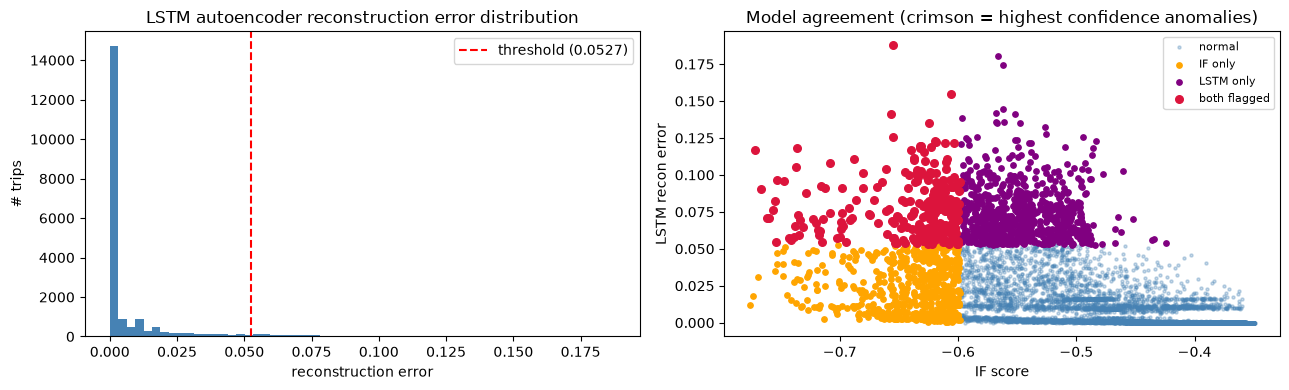

In [7]:
lstm_model, train_errors = an.train_lstm_autoencoder(X, CFG)

# Anomaly threshold = 95th percentile of training errors
threshold = float(np.percentile(train_errors, 95))
lstm_anom = train_errors > threshold
print(f'LSTM threshold (95th pct): {threshold:.5f}')
print(f'LSTM anomalous trips: {lstm_anom.sum()} / {len(train_errors)} '
      f'({100*lstm_anom.mean():.1f}%)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(train_errors, bins=60, color='steelblue', edgecolor='none')
ax[0].axvline(threshold, color='red', ls='--', label=f'threshold ({threshold:.4f})')
ax[0].set_xlabel('reconstruction error'); ax[0].set_ylabel('# trips')
ax[0].set_title('LSTM autoencoder reconstruction error distribution')
ax[0].legend()

# Agreement between IF and LSTM
# Rebuild IF flags aligned with sequence trip_ids
id_cols = list(an.TRIP_KEYS)
id_df = pd.DataFrame(trip_ids, columns=id_cols)
id_df['lstm_anom'] = lstm_anom
id_df['lstm_err'] = train_errors
merged = trips_scored.merge(id_df, on=id_cols, how='inner')
agree = ((merged['anomaly'] == merged['lstm_anom'])).mean()
print(f'\nIF vs LSTM agreement: {100*agree:.1f}%')
both = ((merged['anomaly']) & (merged['lstm_anom'])).sum()
print(f'Flagged by BOTH models: {both} trips (highest confidence anomalies)')

ax[1].scatter(merged.loc[~merged['anomaly'] & ~merged['lstm_anom'], 'if_score'],
              merged.loc[~merged['anomaly'] & ~merged['lstm_anom'], 'lstm_err'],
              s=5, alpha=0.3, color='steelblue', label='normal')
ax[1].scatter(merged.loc[merged['anomaly'] & ~merged['lstm_anom'], 'if_score'],
              merged.loc[merged['anomaly'] & ~merged['lstm_anom'], 'lstm_err'],
              s=15, color='orange', label='IF only')
ax[1].scatter(merged.loc[~merged['anomaly'] & merged['lstm_anom'], 'if_score'],
              merged.loc[~merged['anomaly'] & merged['lstm_anom'], 'lstm_err'],
              s=15, color='purple', label='LSTM only')
ax[1].scatter(merged.loc[merged['anomaly'] & merged['lstm_anom'], 'if_score'],
              merged.loc[merged['anomaly'] & merged['lstm_anom'], 'lstm_err'],
              s=30, color='crimson', zorder=5, label='both flagged')
ax[1].set_xlabel('IF score'); ax[1].set_ylabel('LSTM recon error')
ax[1].set_title('Model agreement (crimson = highest confidence anomalies)')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What this shows:**
- Left: distribution of reconstruction errors across all 20,184 trips. The red threshold line is the 95th percentile — trips above it are flagged as anomalous.
- Right: scatter plot of IF score (x-axis) vs LSTM reconstruction error (y-axis). Each dot is a trip, coloured by which model(s) flagged it.

**Left plot — reconstruction error distribution:**
The distribution should have a strong peak near zero (most trips are easy to reconstruct) and a long tail to the right (the anomalous trips the model couldn't reproduce). The threshold at the 95th percentile means exactly 5% of trips are flagged — this is a design choice, not a learned boundary. You can adjust it: a lower threshold (e.g., 99th percentile) catches only the most extreme anomalies; a higher threshold (e.g., 90th percentile) casts a wider net.

**Right plot — model agreement (the most important chart):**
The four groups tell you how certain each flag is:

| Color | Meaning | Confidence |
|-------|---------|-----------|
| Blue | Normal by both models | High — no concern |
| Orange | Flagged by IF only | Low — aggregate metrics unusual but stop sequence looks normal |
| Purple | Flagged by LSTM only | Medium — something unusual in the stop sequence, but overall trip metrics looked fine |
| Crimson | Flagged by BOTH | **Highest — both a global and a sequential anomaly** |

**Why do the models disagree?**
IF operates on aggregate trip-level features (one vector per trip). LSTM operates on the full stop-by-stop sequence. They can disagree because:
- A trip with one catastrophic stop (LSTM catches it) might have average `max_dwell_s` that is not extreme enough for IF
- A trip with slightly unusual values on multiple features (IF catches it) might have a stop sequence that looks individually normal

**Interpreting the agreement percentage:**
- IF and LSTM agreement ~90%+ means both models see the same anomalies — the anomalies are obvious and consistent
- Agreement ~75–85% means the models are finding partially different things — worth investigating both sets
- The "flagged by BOTH" crimson cluster is the operational watchlist: these are the trips both models agree are genuinely abnormal

## 5. Drill-down: inspect the most anomalous trip

Look at the stop-by-stop dwell profile of the trip with the highest reconstruction error.

Most anomalous trip (LSTM):
{'day': '20250105', 'line': '215', 'societe': 'S.R.T.K', 'bus': np.int64(6028), 'trip_id': np.int64(0)}


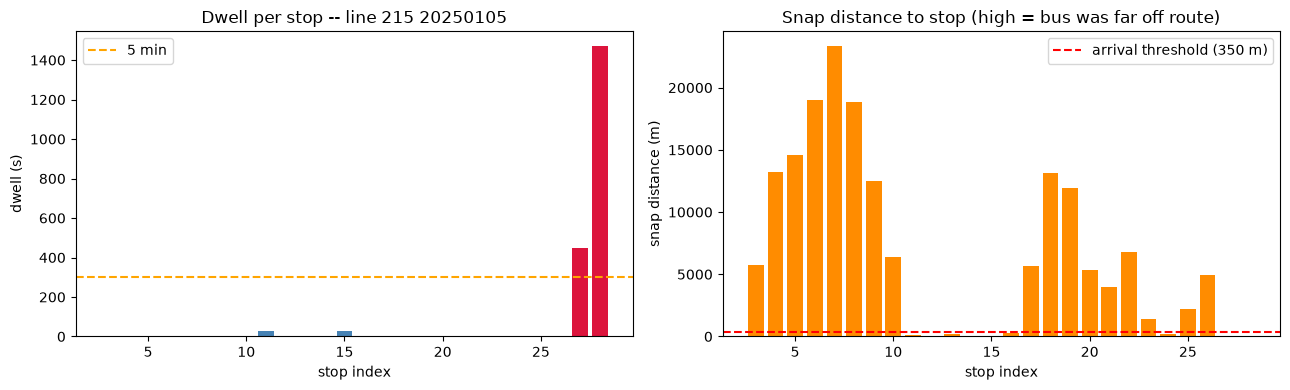

,seq,stop,arrival,departure,dwell_s,dist_m,matched
1031,3,ZELFEN,NaN,NaN,NaN,5712.0,False
1032,4,KHEMOUDA,NaN,NaN,NaN,13220.0,False
1033,5,EL MRAOUNA,NaN,NaN,NaN,14577.0,False
1034,6,BOULAABA,NaN,NaN,NaN,18989.0,False
1035,7,KASSERINE,NaN,NaN,NaN,23358.0,False
1036,8,BOUZGUEM,NaN,NaN,NaN,18811.0,False
1037,9,EL GARRAA,NaN,NaN,NaN,12461.0,False
1038,10,CHRAYA,NaN,NaN,NaN,6396.0,False
1039,11,SBEITLA,06:03:59,06:04:29,30.0,142.0,True
1040,12,M'GHILLA,06:19:29,06:19:29,0.0,37.0,True


In [8]:
worst_idx = int(np.argmax(train_errors))
worst_keys = dict(zip(an.TRIP_KEYS, trip_ids[worst_idx]))
print('Most anomalous trip (LSTM):'); print(worst_keys)

trip_rows = fa[
    (fa['day'] == worst_keys['day']) &
    (fa['line'] == worst_keys['line']) &
    (fa['societe'] == worst_keys['societe']) &
    (fa['bus'] == worst_keys['bus']) &
    (fa['trip_id'] == worst_keys['trip_id'])
].sort_values('seq')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(trip_rows['seq'], trip_rows['dwell_s'].fillna(0),
          color=['crimson' if d > 300 else 'steelblue'
                 for d in trip_rows['dwell_s'].fillna(0)])
ax[0].axhline(300, color='orange', ls='--', label='5 min')
ax[0].set_xlabel('stop index'); ax[0].set_ylabel('dwell (s)')
ax[0].set_title(f'Dwell per stop -- line {worst_keys["line"]} {worst_keys["day"]}')
ax[0].legend()

ax[1].bar(trip_rows['seq'], trip_rows['dist_m'].fillna(0), color='darkorange')
ax[1].axhline(350, color='red', ls='--', label='arrival threshold (350 m)')
ax[1].set_xlabel('stop index'); ax[1].set_ylabel('snap distance (m)')
ax[1].set_title('Snap distance to stop (high = bus was far off route)')
ax[1].legend()
plt.tight_layout(); plt.show()

display(trip_rows[['seq','stop','arrival','departure','dwell_s','dist_m','matched']]
        .assign(arrival=lambda d: d['arrival'].dt.strftime('%H:%M:%S'),
                departure=lambda d: d['departure'].dt.strftime('%H:%M:%S')))

**What this shows:** The stop-by-stop breakdown of the single most anomalous trip according to the LSTM autoencoder. Left = dwell time per stop (red bars = > 5 minutes). Right = how far the bus's GPS was from each stop coordinate.

**How to read the left chart (dwell per stop):**
- Bars staying below the orange 5-minute line = normal operation
- One or a few tall crimson bars = specific stops where something went wrong
- All bars tall = the bus was slow throughout the entire trip, not just at one stop

**The pattern you're looking for:**
- **Single giant spike** → breakdown at a specific stop (vehicle issue, accident, road blockage)
- **Spike at stop 0 or stop N** → the bus sat at the terminus for hours before departing or after arriving (GPS left on during layover)
- **All stops high** → systemic delay across the whole trip (e.g., severe traffic, passengers boarding slowly everywhere)

**How to read the right chart (snap distance):**
- All bars near zero = GPS tracking was accurate throughout, bus stayed on route
- One tall orange bar = at that stop, the GPS put the bus far from the road (temporary GPS error, bus took a detour, or stop coordinates are wrong)
- Bars near or above the 350m red threshold = stops that were barely matched (close to being unmatched)

**Combining both charts:**
The most telling anomalies are stops where **both** dwell is high AND snap distance is high simultaneously — the bus was far from the stop AND sitting still for a long time. That combination strongly suggests the bus broke down between stops and the closest GPS match was inaccurate.

**The table below the charts** gives the exact arrival/departure timestamps for each stop — you can calculate precise dwell at each stop and identify the exact time range when the incident occurred. That timestamp is what a company's dispatch team would use to correlate with driver reports or maintenance logs.

### Takeaways & next steps

- **Isolation Forest** flags ~5% of trips as anomalous based on aggregate features. The biggest discriminators are `max_dwell_s` and `dist_m_max` -- a bus that sat for a long time or drifted far from the route.
- **LSTM Autoencoder** finds the stop *within* a trip where the pattern breaks. High reconstruction error = the model has never seen a stop sequence like this.
- **Both models agree** on the clearest incidents. Use single-model flags as soft warnings and dual-model agreement as high-confidence alerts.
- **No labels yet:** without incident reports from the companies we cannot compute precision/recall. The companies can validate flagged trips to calibrate thresholds.
- **Next:** Module 4 -- RAG chatbot that lets operators query all of this data in plain language.